In [1]:
pip install miditok


In [2]:
pip install torch

In [3]:
pip install music21

In [4]:
pip install librosa pydub midi2audio IPython


In [ ]:
import os
os.environ["XLA_MODEL_PARALLEL"] = "1"

In [5]:
import torch
import torch_xla

/usr/local/lib/python3.12/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.5.1)/charset_normalizer (3.4.9) doesn't match a supported version!
  warnings.warn(


In [6]:
import torch_xla.core.xla_model as xm
import torch_xla.distributed.xla_multiprocessing as xmp

In [29]:
from torch_xla.distributed.parallel_loader import MpDeviceLoader

In [30]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch.utils.data.dataloader")


In [7]:
from miditok import REMI, TokenizerConfig
from miditok.utils import split_files_for_training
from miditok.pytorch_data import DatasetMIDI, DataCollator
from torch.utils.data import DataLoader
from pathlib import Path

from miditok import REMI
tokenizer = REMI(params="/content/MIDI-LSTM-and-transformer-decoder/trained_tokenizer/tokenizer.json")


/usr/local/lib/python3.12/dist-packages/miditok/tokenizations/remi.py:88: UserWarning: Attribute controls are not compatible with 'config.one_token_stream_for_programs' and multi-vocabulary tokenizers. Disabling them from the config.
  super().__init__(tokenizer_config, params)


In [8]:
tokenizer.vocab_size


20000

In [11]:
import zipfile
import os

def extract_datasets(zip_path,extract_path):
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      erro = zip_ref.testzip()
      return zip_ref.extractall(extract_path)

In [12]:
training_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_training.zip","/content/dataset_training")

test_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_test.zip","/content/dataset_test")

validation_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_validation.zip","/content/dataset_validation")


In [10]:
training_path = list(Path("/content/dataset_training").glob("**/*.mid"))
test_path = list(Path("/content/dataset_test").glob("**/*.mid"))
validation_path = list(Path("/content/dataset_validation").glob("**/*.mid"))

In [11]:
print(len(training_path))
print(len(test_path))
print(len(validation_path))

15175
5951
2678


In [14]:
dataset_chunks_dir = Path("/content/training_chunked")

In [12]:
max_seq_len = 512
batch_size = 128
hidden_dim = 128
epochs = 5
embed_dim = 64
num_layers = 4
name_model = "pesos_lstm.pt"
version=3
complete_path = f"/content/MIDI-LSTM-and-transformer-decoder/training/{version}/"

In [15]:
# Split MIDIs into smaller chunks for training
split_files_for_training(
    files_paths=training_path,
    tokenizer=tokenizer,
    save_dir=dataset_chunks_dir,
    max_seq_len=max_seq_len,
)
print(split_files_for_training) #512, 1024, or 2048 tokens

Splitting music files (/content/training_chunked): 100%|██████████| 15175/15175 [00:27<00:00, 556.21it/s]

<function split_files_for_training at 0x7d32e150b9c0>


In [16]:
dataset_training = DatasetMIDI(
    files_paths=list(dataset_chunks_dir.glob("**/*.mid")),
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_training)

120505 files.


In [17]:
dataset_test = DatasetMIDI(
    files_paths=test_path,
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_test)

5951 files.


In [18]:
dataset_validation = DatasetMIDI(
    files_paths=validation_path,
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_validation)

2678 files.


In [19]:
collator = DataCollator(tokenizer.pad_token_id, copy_inputs_as_labels=True, shift_labels=True)


In [20]:
dataloader_test = DataLoader(dataset_test, batch_size=batch_size,num_workers=0, persistent_workers=False, collate_fn=collator,drop_last=True)

dataloader_validation = DataLoader(dataset_validation, batch_size=60, collate_fn=collator)

In [21]:
import random

def generate_sample_input_predict(dataloader_validation):
  valor=random.randint(1, len(dataloader_validation))
  counter = 1
  for batch in dataloader_validation:
    if counter == valor:
      return batch["input_ids"]
    counter=counter+1

In [22]:
import torch
import torch.nn as nn

class MusicGeneratorLSTM(nn.Module):
    def __init__(self, vocab_size,embed_dim,hidden_dim,num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size,embed_dim)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.lstm(emb, hidden)
        logits = self.fc(out)
        return logits, hidden

In [23]:
from pathlib import Path

def converte_output_to_midi(lstm_output, name):
  lstm_output.dump_midi(Path(f"{name}.mid"))


In [24]:
from music21 import converter

def tonal_estimator(music):
  score = converter.parse(music)
  key = score.analyze("key")

  print(key)
  print(f"Tônica: {key.tonic.name} e modo: {key.mode}")
  print(f"Consistência tonal: {key.correlationCoefficient}")
  print(f"Melhor tonalidade: {key.tonalCertainty()}")

In [25]:
from collections import defaultdict
import matplotlib.pyplot as plt
import librosa

def counter_notes(music):
  counter_bar = defaultdict(int)
  counter_pitch = defaultdict(int)
  counter_velocity = defaultdict(int)

  for token in music:
    if "bar" in token.lower():
        pass
    #altura das notas
    elif "velocity" in token.lower():
      velocity = int(token.split("_")[1])
      counter_velocity[velocity] += 1
    # Quando encontra um Pitch (Note On)
    elif "pitch" in token.lower():
        pitch_val = int(token.split("_")[1])
        pitch_note = librosa.midi_to_note(pitch_val)
        counter_pitch[pitch_note] += 1

  plt.figure(figsize=(20, 10))
  majors_pitch = sorted(counter_pitch.items(), key=lambda x: x[1], reverse=True)
  majors_velocity = sorted(counter_velocity.items(), key=lambda x: x[1], reverse=True)
  x_pitch,y_pitch = zip(*majors_pitch)
  plt.bar(x_pitch,y_pitch, color='skyblue')

  plt.title('Notas mais tocadas')
  plt.xlabel('Notas')
  plt.ylabel('Quantidade')

  plt.show()
  print()
  print()
  x_vel,y_vel = zip(*majors_velocity)
  plt.bar(x_vel,y_vel, color='skyblue')

  plt.title('Altura mais tocadas')
  plt.xlabel('Altura')
  plt.ylabel('Quantidade')

  plt.show()

In [26]:
def treinar_na_tpu(index,dataset_training, collator, batch_size,hidden_dim, embed_dim, num_layers, epochs, complete_path, name_model):
    device = torch_xla.device()
    dataloader_training = MpDeviceLoader(DataLoader(dataset_training, batch_size=batch_size, num_workers=4, pin_memory=False, persistent_workers=True,
    prefetch_factor=4, collate_fn=collator,drop_last=True), device)

    model = MusicGeneratorLSTM(vocab_size=tokenizer.vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters())
    epoch_loss = 0.0
    counter = 0

    hidden_train = (
        torch.zeros(num_layers, batch_size, hidden_dim, device=device),
        torch.zeros(num_layers, batch_size, hidden_dim, device=device)
    )

    print(f"Tamanho do lote de treinamento: {len(dataloader_training)}",flush=True)
    print(f"Tamanho da época: {epochs}",flush=True)

    created_path = Path(complete_path).mkdir(parents=True, exist_ok=True)


    for epoch in range(epochs):
      for batch in dataloader_training:
          optimizer.zero_grad()

          # Pega os dados já fatiados pelo MidiTok
          inputs = batch["input_ids"].to(device)
          targets = batch["labels"].to(device)
          outputs, hidden_train = model(inputs, hidden_train)
          loss = criterion(outputs.reshape(-1, tokenizer.vocab_size), inputs.reshape(-1))
          loss.backward()
          torch_xla.sync()
          xm.optimizer_step(optimizer)
          epoch_loss += loss.detach().item()
          if isinstance(hidden_train, tuple): # Para LSTMs (h_n, c_n)
              hidden_train = (hidden_train[0].detach(), hidden_train[1].detach())
          counter = counter +1
          break
      print(f"Finalizando época: {epoch}",flush=True)
    xm.save(model.state_dict(), complete_path+name_model)

    # Exibe a média real de perda de toda a época
    print(f"Perda média treinamento: {epoch_loss / len(dataloader_training):.4f}", flush=True)

    perplexity_treinamento = torch.exp(torch.tensor(epoch_loss))
    print("Perplexidade treinamento:", perplexity_treinamento.item(), flush=True)


In [27]:
path_model = f"{complete_path}{name_model}"

path_music = f"{complete_path}music-{version}"

In [31]:
xmp.spawn(
    treinar_na_tpu,
    args=(dataset_training, collator, batch_size,hidden_dim, embed_dim,num_layers, epochs, complete_path, name_model),
    nprocs=1,
    start_method='fork'
)

Tamanho do lote de treinamento: 941
Tamanho da época: 5


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Finalizando época: 0
Finalizando época: 1
Finalizando época: 2
Finalizando época: 3
Finalizando época: 4
Perda média treinamento: 0.0524
Perplexidade treinamento: 2.705338473334291e+21


In [32]:
device_test = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
path_model = f"{complete_path}{name_model}"
model_t_v = MusicGeneratorLSTM(vocab_size=tokenizer.vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers)
state_dict = torch.load(path_model,map_location=device_test)
model_t_v.load_state_dict(state_dict)
model_t_v.to(device_test)
model_t_v.eval()


MusicGeneratorLSTM(
  (embedding): Embedding(20000, 64)
  (lstm): LSTM(64, 128, num_layers=4, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=20000, bias=True)
)

In [34]:
total_loss = 0.0
criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    hidden_test = None
    for batch in dataloader_test:
        if hidden_test is not None:
            hidden_test = (hidden_test[0].detach(), hidden_test[1].detach())
        inputs = batch["input_ids"]
        targets = batch["labels"]

        outputs, hidden_test = model_t_v(inputs, hidden_test)

        loss = criterion(outputs.reshape(-1, tokenizer.vocab_size), targets.reshape(-1))
        total_loss += loss.item()

mean_loss = total_loss / len(dataloader_test)
print(f"Perda média no teste: {mean_loss}")

mean_loss_tensor = torch.tensor(mean_loss)

perplexity_teste = torch.exp(mean_loss_tensor)
print(f"Perplexidade no teste: {perplexity_teste.item()}")



Perda média no teste: 9.851771831512451
Perplexidade no teste: 18991.984375


In [35]:
def make_prediction(model, dataloader_validation, steps=0):
  inputs = generate_sample_input_predict(dataloader_validation)
  hidden = None
  for _ in range(steps):
    with torch.no_grad():
      outputs, hidden = model(inputs, hidden)
      next_token_tensor = outputs[:, -1, :].argmax(-1,keepdim=True)
      inputs = torch.cat([inputs, next_token_tensor],dim=1)
  return inputs[0]



In [36]:
music_predicted = make_prediction(model_t_v, dataloader_validation, steps=50)

In [37]:
music_decoded = tokenizer(music_predicted)
print(music_decoded)

Score(ttype=Tick, tpq=8, begin=0, end=1429, tracks=1, notes=311, time_sig=1, key_sig=0, markers=0)


In [38]:
midi = tokenizer(music_decoded)
print(midi)

TokSequence(tokens=['Bar_None', 'Position_0', 'Tempo_121.29', 'Bar_None', 'Position_6', 'Program_0', 'Pitch_62', 'Velocity_55', 'Duration_1.0.8', 'Program_0', 'Pitch_71', 'Velocity_55', 'Duration_1.0.8', 'Program_0', 'Pitch_55', 'Velocity_55', 'Duration_2.4.8', 'Position_16', 'Program_0', 'Pitch_63', 'Velocity_51', 'Duration_1.0.8', 'Program_0', 'Pitch_71', 'Velocity_55', 'Duration_1.0.8', 'Position_25', 'Program_0', 'Pitch_48', 'Velocity_55', 'Duration_3.5.8', 'Program_0', 'Pitch_69', 'Velocity_59', 'Duration_1.6.8', 'Program_0', 'Pitch_64', 'Velocity_59', 'Duration_2.1.8', 'Bar_None', 'Position_7', 'Program_0', 'Pitch_71', 'Velocity_55', 'Duration_0.2.8', 'Position_10', 'Program_0', 'Pitch_72', 'Velocity_55', 'Duration_0.2.8', 'Position_12', 'Program_0', 'Pitch_64', 'Velocity_55', 'Duration_1.1.8', 'Position_21', 'Program_0', 'Pitch_60', 'Velocity_55', 'Duration_1.2.8', 'Program_0', 'Pitch_66', 'Velocity_55', 'Duration_1.2.8', 'Program_0', 'Pitch_50', 'Velocity_55', 'Duration_1.2.8',

In [39]:
music_to_midi = converte_output_to_midi(music_decoded, path_music)
print(music_decoded)

Score(ttype=Tick, tpq=8, begin=0, end=1429, tracks=1, notes=311, time_sig=1, key_sig=0, markers=0)


In [40]:
tonal_estimator(f"/content/{name_model}.mid")

e minor
Tônica: E e modo: minor
Consistência tonal: 0.9349818571626636
Melhor tonalidade: 1.341688824486821


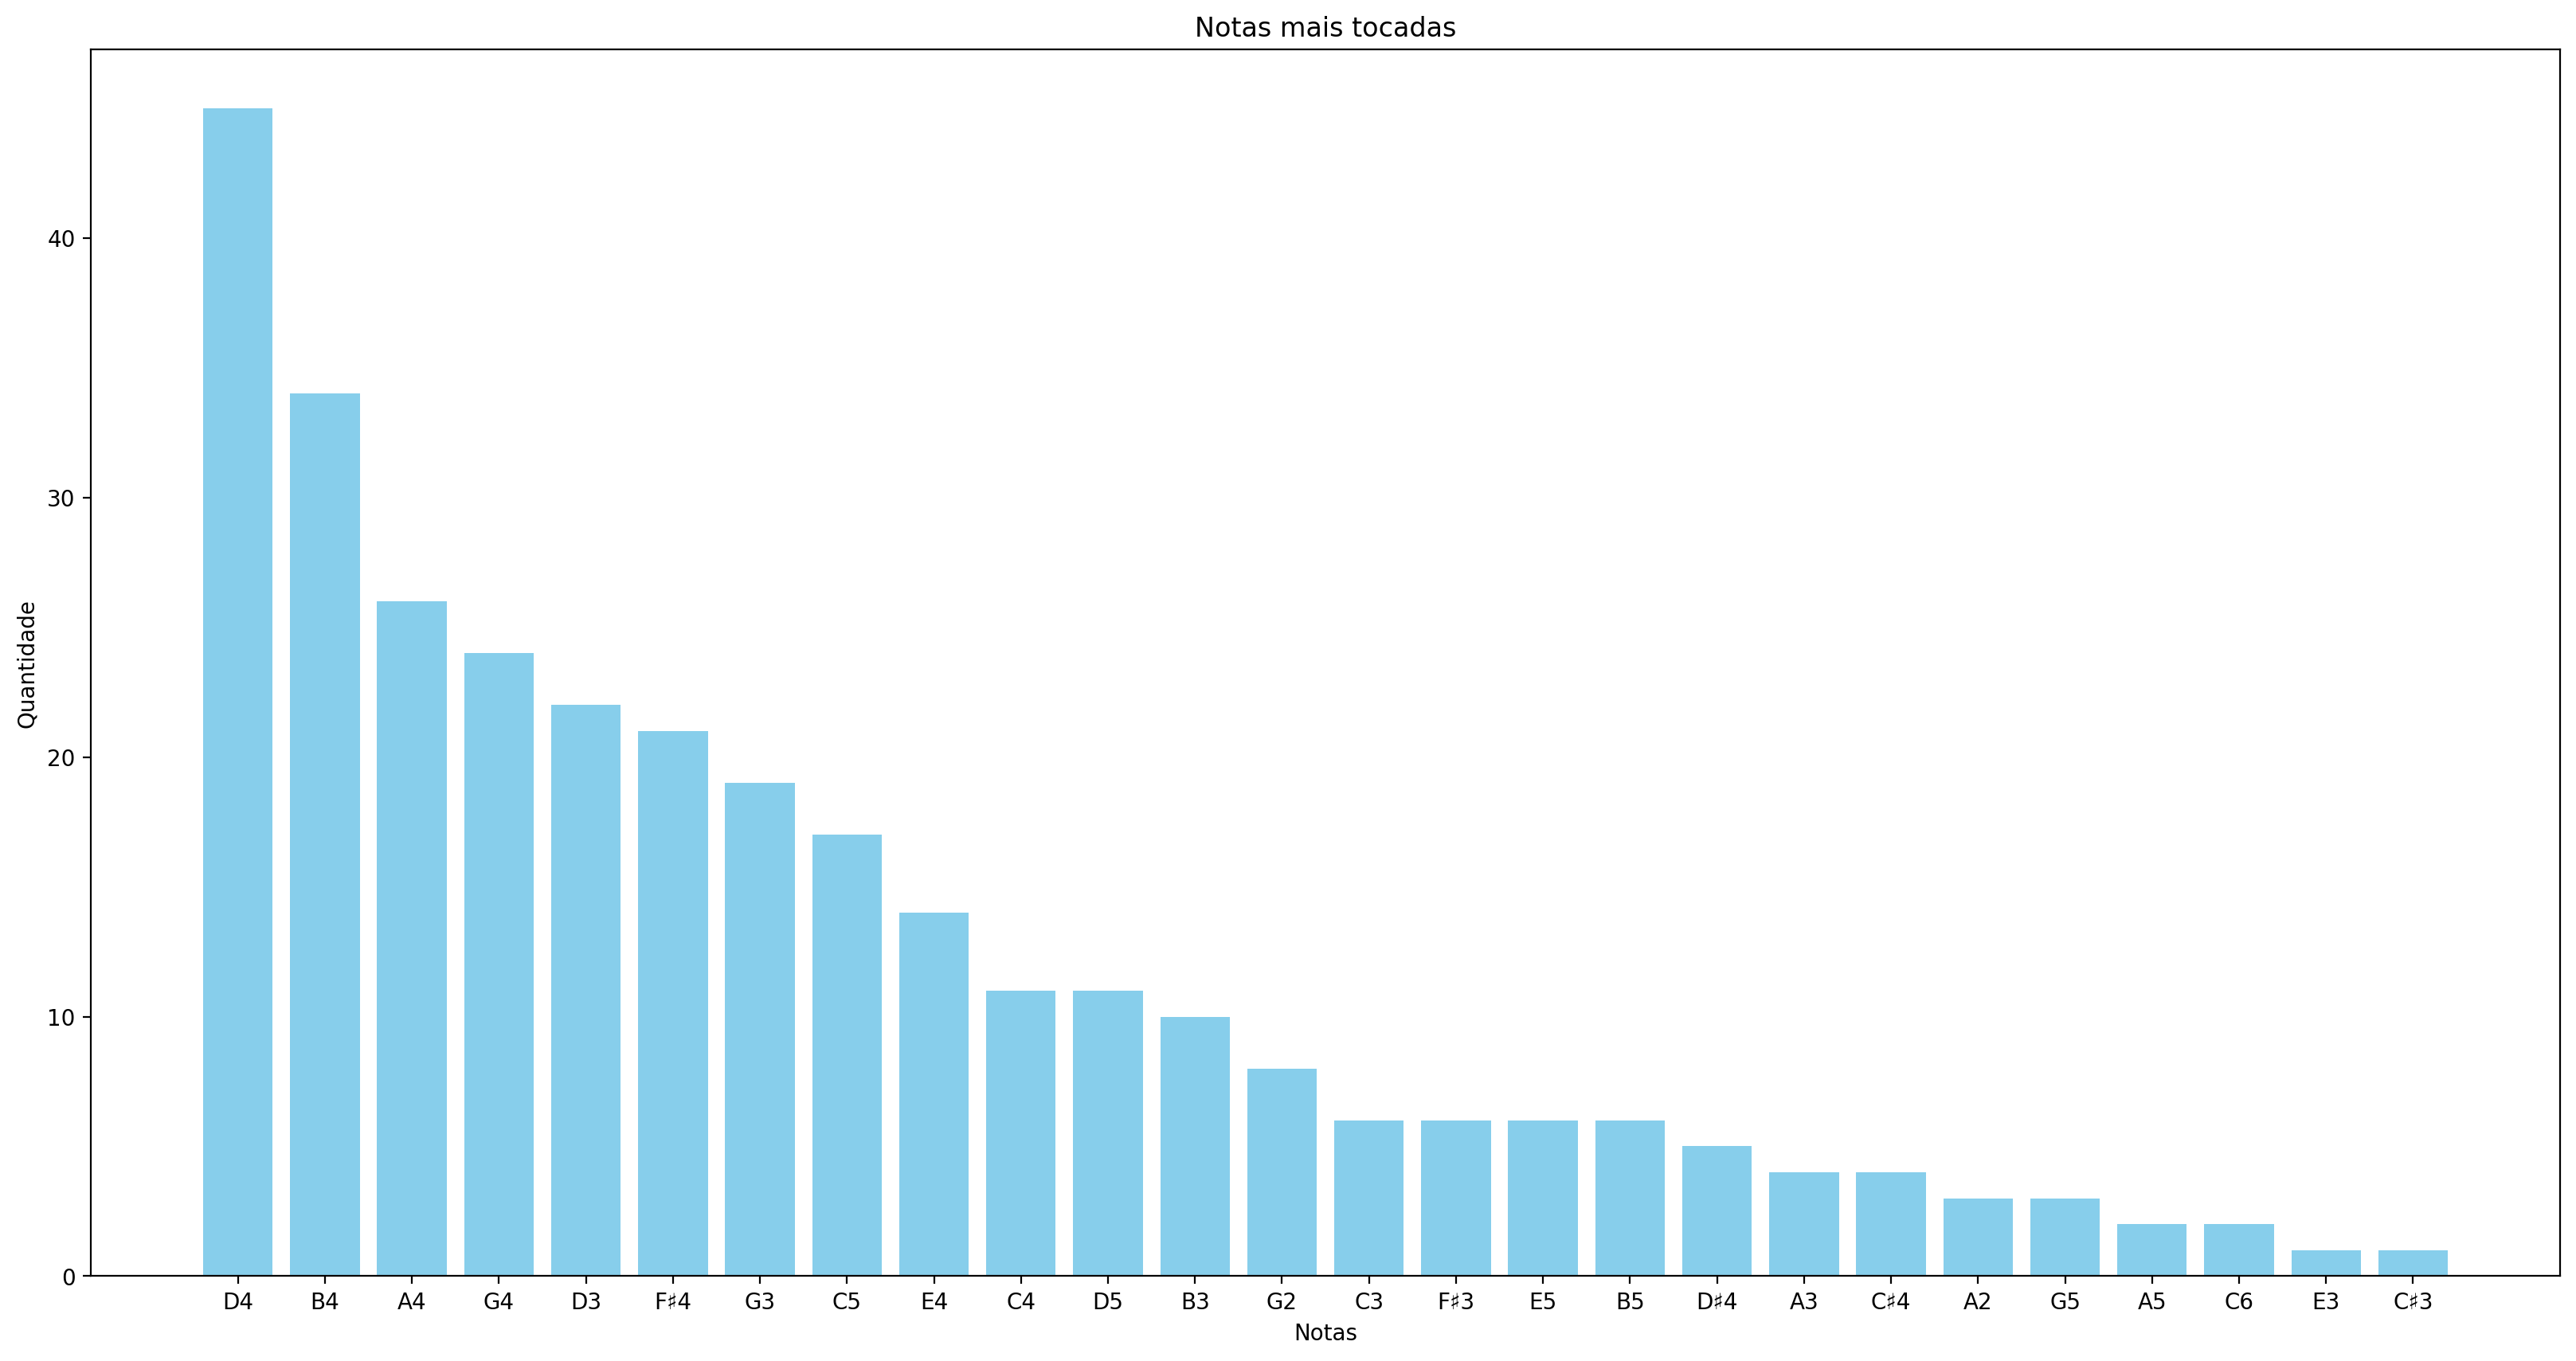

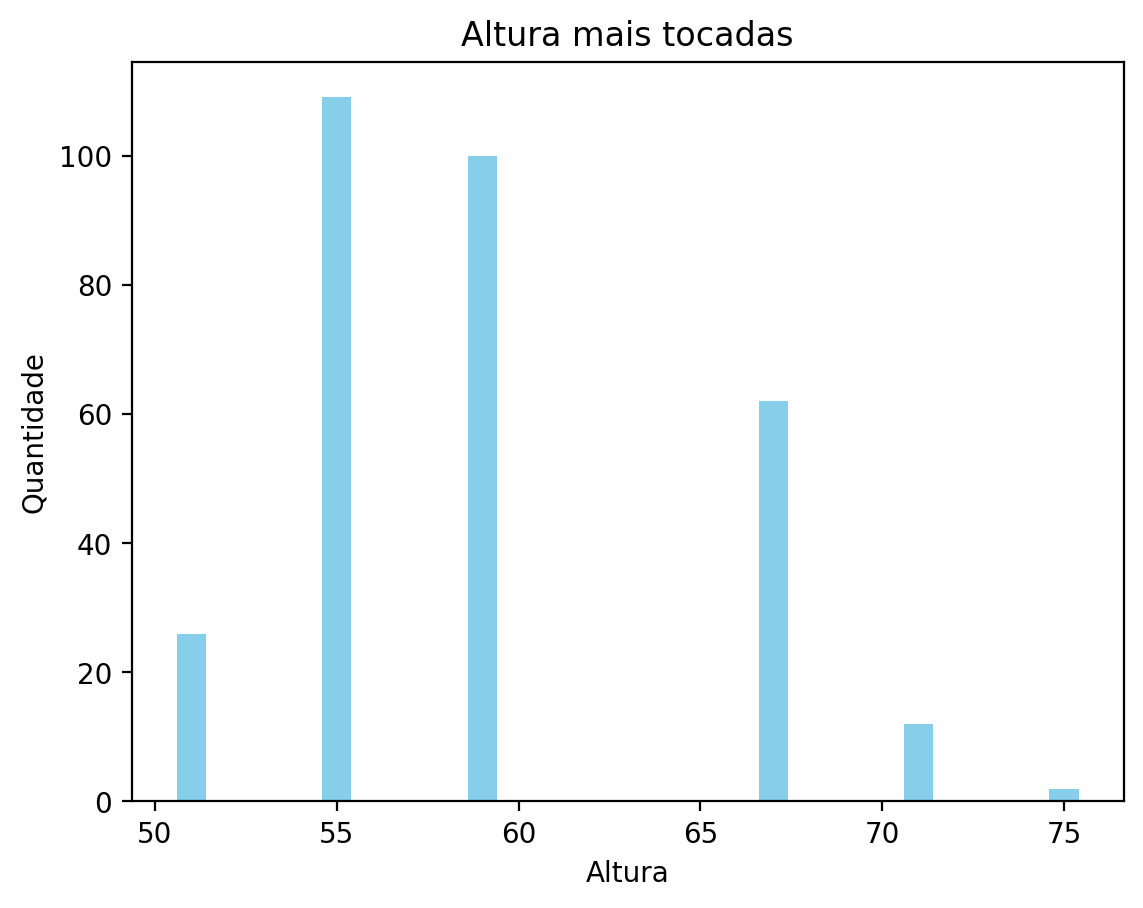

In [41]:
counter_notes(midi.tokens)